# AML - Butterflies

This project aims to develop a 3 differente models of Neural Networks (MLP, CNN and ResNets), with different Loss functions

## Files Setup

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies')
   
    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning/aca-butterflies')

if not path.exists():
    raise FileNotFoundError(f"The specified path does not exist: {path}")

print(f"Using path: {path}")

Using path: /content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies


### Load data to Colab

In this section we load the images data to Colab´s server, so it´s now stored at Google´s memory and the code runs so much faster.

Note: add a code cell bellow with the path to your zip file (tip: add it to the same folder as the project, the .gitignore is ok!)

In [3]:
# Load the dataset on Colab machine
!cp "/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip" "/content/butterflies.zip"

In [4]:
!unzip -q /content/butterflies.zip -d /content/dataset_local

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings("ignore")

In [6]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


### Dataset manipulation class

In [7]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [8]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [9]:
# load the data
img_dir = "/content/dataset_local/aca-butterflies/train"
# img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
print(f"Dataset size: {len(dataset)} samples")
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 5199 samples


In [10]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


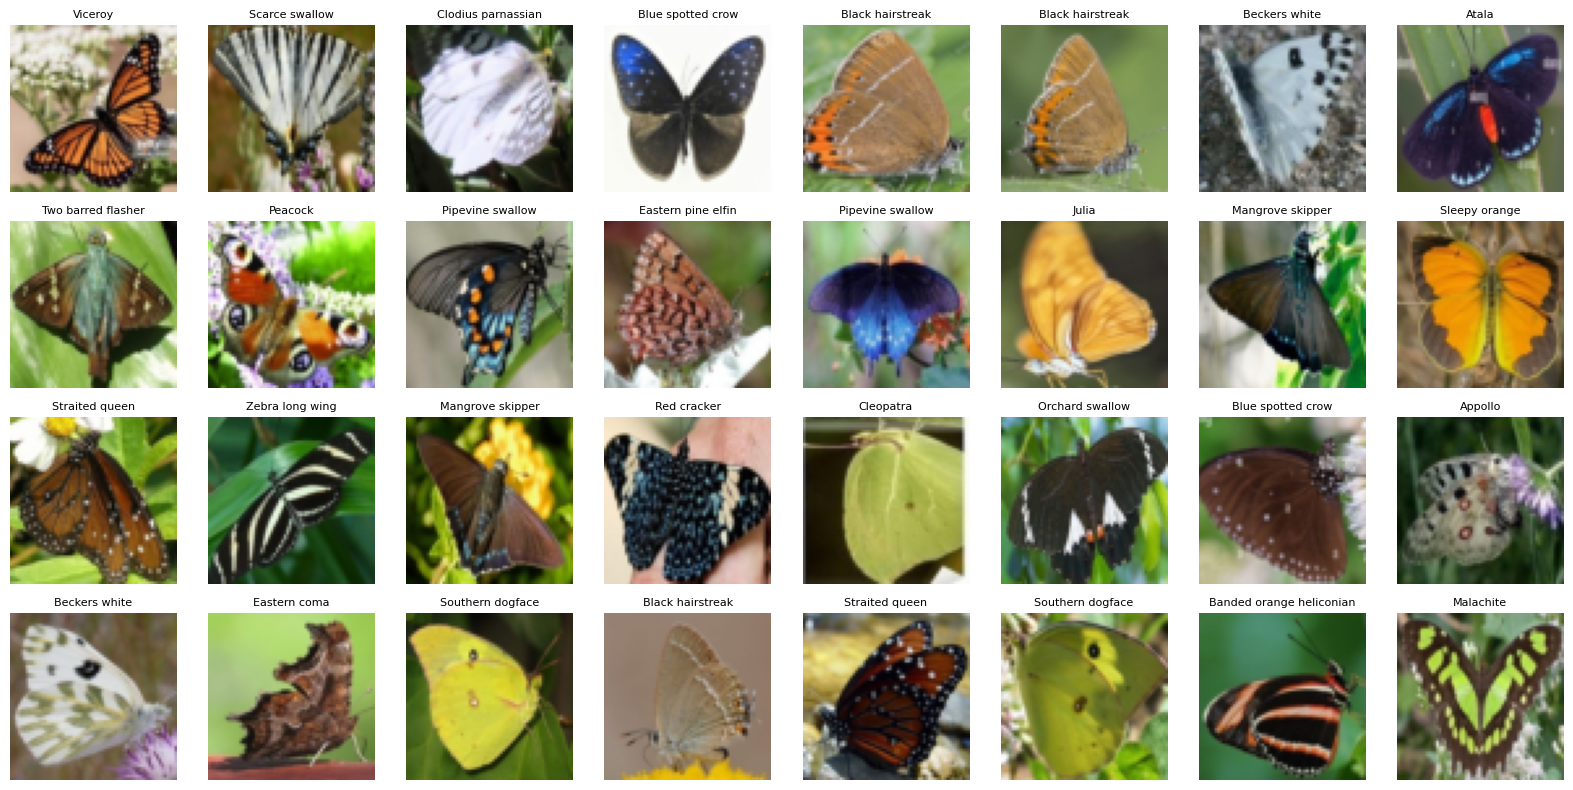

In [11]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    # permutation compute for Matplotlib (C, H, W) -> (H, W, C)
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Dataset analysis

As part of the Data Science pipeline, we first do an Exploratory Data Analysis, let´s see the distribution of the classes in the dataset.

**Inbalanced dataset = model w/ bias**

### Class distribution

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64


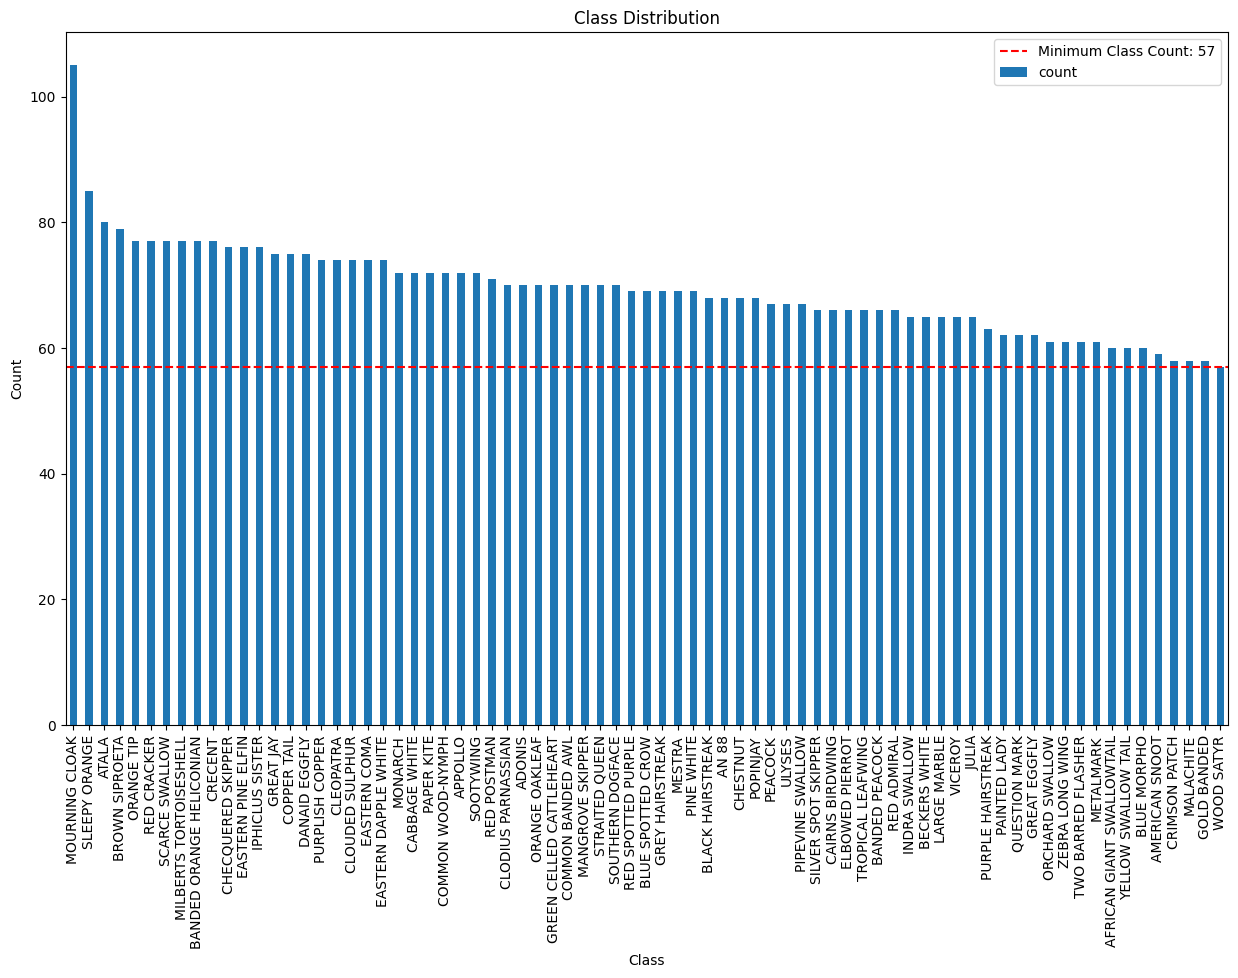

In [13]:
# Compute class distribution
import matplotlib.pyplot as plt

class_counts = df['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(15, 9))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.min(), color='red', linestyle='--', label=f'Minimum Class Count: {class_counts.min()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()

At first analysis the dataset was deeply unbalanced, so we must to explore different techniques to deal with this issue

## Oversampling

**Attention: to perform only 1 time!**

It consists on create new sintetic samples of the minorities classes by transforming the images

In [ ]:
import random

random.seed(42)

majority_class = class_counts.idxmax()
minority_classes = class_counts[class_counts < class_counts.max()].index

print(f"Majority class: {majority_class} with {class_counts.max()} samples")
print(f"Minority classes length: {len(minority_classes)}")


for minority_class in minority_classes:
    minority_count = class_counts[minority_class]
    majority_count = class_counts[majority_class]
    samples_to_add = majority_count - minority_count

    print(f"Class '{minority_class}' has {minority_count} samples. Adding {samples_to_add} samples to match the majority class.")

    # Get all images of the minority class
    minority_images = df[df['label'] == minority_class]['filename'].tolist()

    # Randomly sample images from the minority class to create new samples
    for _ in range(samples_to_add):
        img_name = random.choice(minority_images)
        img_path = os.path.join(img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        # Apply random transformations
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

        transformed_image = transform(image)

        # Save the transformed image with a new name
        new_img_name = f"{minority_class}_aug_{_}.jpg"
        new_img_path = os.path.join(img_dir, new_img_name)
        transformed_image_pil = transforms.ToPILImage()(transformed_image)
        transformed_image_pil.save(new_img_path)

        # Add the new sample to the dataframe
        new_row = pd.DataFrame([{'filename': new_img_name, 'label': minority_class}])
        df = pd.concat([df, new_row], ignore_index=True)

# Verify the new class distribution
new_class_counts = df['label'].value_counts()
print("New class distribution after oversampling:")
print(new_class_counts)

Majority class: MOURNING CLOAK with 105 samples
Minority classes length: 74
Class 'SLEEPY ORANGE' has 85 samples. Adding 20 samples to match the majority class.
Class 'ATALA' has 80 samples. Adding 25 samples to match the majority class.
Class 'BROWN SIPROETA' has 79 samples. Adding 26 samples to match the majority class.
Class 'ORANGE TIP' has 77 samples. Adding 28 samples to match the majority class.
Class 'RED CRACKER' has 77 samples. Adding 28 samples to match the majority class.
Class 'SCARCE SWALLOW' has 77 samples. Adding 28 samples to match the majority class.
Class 'MILBERTS TORTOISESHELL' has 77 samples. Adding 28 samples to match the majority class.
Class 'BANDED ORANGE HELICONIAN' has 77 samples. Adding 28 samples to match the majority class.
Class 'CRECENT' has 77 samples. Adding 28 samples to match the majority class.
Class 'CHECQUERED SKIPPER' has 76 samples. Adding 29 samples to match the majority class.
Class 'EASTERN PINE ELFIN' has 76 samples. Adding 29 samples to ma

In [ ]:
print("New shape of the dataset after oversampling:", df.shape)

plt.figure(figsize=(15, 9))
new_class_counts.plot(kind='bar')
plt.title('New Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.max(), color='green', linestyle='--', label=f'Majority Class Count: {class_counts.max()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()


New shape of the dataset after oversampling: (5199, 2)


NameError: name 'new_class_counts' is not defined

<Figure size 1500x900 with 0 Axes>

In [ ]:
df.head()
df.to_csv(os.path.join(path, 'train_oversampled.csv'), index=False)

## Class Weighting

We compute the classes weights on the dataset and save on a Tensor



### Compute the class weights for each class

In [12]:
df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# Compute class distribution for the original dataset
class_counts = df_original['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Compute the weight for each class
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
print("\nClass weights:")
print(class_weights)

# Convert to tensors
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)
print("\nClass weights tensor:")
print(class_weights_tensor)

loss = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

dataset = ButterflyDataset(df=df_original, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64

Class weights:
label
MOURNING CLOAK    0.653473
SLEEPY ORANGE     0.807232
ATALA             0.857684
BROWN SIPROETA    0.868540
ORANGE TIP        0.891100
                    ...   
AMERICAN SNOOT    1.162961
CRIMSON PATCH     1.183012
MALACHITE         1.183012
GOLD BANDED       1.183012
WOOD SATYR        1.203767
Name: count, Length: 75, dtype: float64

Class weights tensor:
tensor([0.6535, 0.8072, 0.8577, 0.8685, 0.8911, 0.8911, 0.8911, 0.8911, 0.8911,
        0.8911, 0.9028, 0.9028, 0.9028, 0.9149, 0.9149, 0.9149, 0.9272, 0.9272,
        0.9272, 0.9272, 0.9272, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530,
        0.9664, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 

### WeightedRandomSampler

In [13]:
from torch.utils.data import WeightedRandomSampler

df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# 1. Contiamo quante immagini ci sono per ogni specie
class_counts = df_original['label'].value_counts()
print("Class counts:", class_counts)

# 2. Calcoliamo i pesi (più la classe è rara, più alto è il peso)
weights = (1.0 / class_counts).to_dict()
print("Class weights:", weights)


# 3. Mappiamo ogni riga del DataFrame al suo peso corrispondente
# Questo trasforma i nomi in numeri (pesi) automaticamente
sample_weights = df_original['label'].map(weights).tolist()

# 3. Creiamo il sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 4. Creiamo il DataLoader (fondamentale: shuffle deve essere False se usi il sampler)
train_loader = data.DataLoader(dataset, batch_size=32, sampler=sampler)

print("Sampler configurato e pronto!")

print("✅ Sampler creato con successo!")
print(f"Esempio primi 3 pesi nella lista: {sample_weights[:3]}")

Class counts: label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64
Class weights: {'MOURNING CLOAK': 0.009523809523809525, 'SLEEPY ORANGE': 0.011764705882352941, 'ATALA': 0.0125, 'BROWN SIPROETA': 0.012658227848101266, 'ORANGE TIP': 0.012987012987012988, 'RED CRACKER': 0.012987012987012988, 'SCARCE SWALLOW': 0.012987012987012988, 'MILBERTS TORTOISESHELL': 0.012987012987012988, 'BANDED ORANGE HELICONIAN': 0.012987012987012988, 'CRECENT': 0.012987012987012988, 'CHECQUERED SKIPPER': 0.013157894736842105, 'EASTERN PINE ELFIN': 0.013157894736842105, 'IPHICLUS SISTER': 0.013157894736842105, 'GREAT JAY': 0.013333333333333334, 'COPPER TAIL': 0.013333333333333334, 'DANAID EGGFLY': 0.013333333333333334, 'PURPLISH COPPER': 0.013513513513513514, 'CLEOPATRA': 0.01351351

In [14]:
# Verify the sampler by checking the distribution of classes in a few batches
images, labels = next(iter(train_loader))

# 2. count the lables in the batch
unique, counts = torch.unique(labels, return_counts=True)

print("--- CHECK BATCH ---")
print(f"Batch dimension: {labels.size(0)} immagini")
print(f"Different classes in this batch: {len(unique)}")
print("\nBatch distribution (Class: Count):")
for u, c in zip(unique, counts):
    print(f"Specie {u.item()}: present {c.item()} times")

# 3. Verifica visiva
if len(unique) > 10:
    print("\n✅ IL SAMPLER FUNZIONA: Il batch contiene molte classi diverse.")
else:
    print("\n⚠️ ATTENZIONE: Se vedi sempre la stessa classe, c'è un problema.")

--- CHECK BATCH ---
Batch dimension: 32 immagini
Different classes in this batch: 25

Batch distribution (Class: Count):
Specie 2: present 1 times
Specie 6: present 1 times
Specie 8: present 1 times
Specie 9: present 1 times
Specie 10: present 1 times
Specie 18: present 1 times
Specie 20: present 1 times
Specie 21: present 1 times
Specie 23: present 1 times
Specie 24: present 1 times
Specie 29: present 1 times
Specie 31: present 3 times
Specie 32: present 1 times
Specie 38: present 2 times
Specie 39: present 1 times
Specie 41: present 3 times
Specie 45: present 1 times
Specie 46: present 1 times
Specie 48: present 2 times
Specie 52: present 1 times
Specie 53: present 1 times
Specie 56: present 2 times
Specie 64: present 1 times
Specie 68: present 1 times
Specie 69: present 1 times

✅ IL SAMPLER FUNZIONA: Il batch contiene molte classi diverse.


In [ ]:
from torch.utils.data import WeightedRandomSampler

def create_weighted_sampler(df, label_col='label'):
    """
    Creates a WeightedRandomSampler to handle class imbalance in the dataset.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the data (e.g., train_df).
        label_col (str): The name of the column containing the classes (default: 'label').
        
    Returns:
        WeightedRandomSampler: The configured sampler to be used in the DataLoader.
    """
    
    # 1. Count how many images there are for each class
    class_counts = df[label_col].value_counts()
    
    # 2. Calculate the weights (1 / frequency of the class)
    weights = (1.0 / class_counts).to_dict()
    
    # 3. Map each row of the DataFrame to its corresponding weight
    sample_weights = df[label_col].map(weights).tolist()
    
    # It's good practice to convert the list of weights to a PyTorch Tensor
    sample_weights_tensor = torch.tensor(sample_weights, dtype=torch.float)
    
    # 4. Create the sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights_tensor, 
        num_samples=len(sample_weights_tensor), 
        replacement=True
    )
    
    return sampler

## Preparation

### Modeling Preparation

In this section we will slip our train dataset in Train, validation and test sets. Because the "test" set that we have doesnt has labels.

Also we define the train function to all NNs

In [ ]:
from sklearn.model_selection import train_test_split

# 1.First we split the data into training/validation (85%) and test (15%)
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.15, 
    random_state=42, 
    stratify=df['label'] 
)

# 2. Then, we split the remaining data between training and validation
# 0.176 aprox represents 15% of the original total (0.15 / 0.85)
train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.176, 
    random_state=42, 
    stratify=train_val_df['label']
)

print(f"Training: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#* Sampler
sampler = create_weighted_sampler(train_df, label_col='label')

#* DataLoaders
# Training
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_loader = data.DataLoader(train_dataset, batch_size=32, sampler=sampler)

# Validation
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_loader = data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# Test
test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_loader = data.DataLoader(test_dataset, batch_size=32, shuffle=False)

Training: 3641 | Validation: 778 | Test: 780


In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    """Function to train the model and return the history of training and validation loss and accuracy.
    Args:
        model: the neural network model to train
        train_loader: DataLoader for the training set
        val_loader: DataLoader for the validation set
        criterion: loss function
        optimizer: optimization algorithm
        num_epochs: number of epochs to train"""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print(f"Starting training of {model.name} on {device}...")
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss = train_running_loss / train_total
        train_acc = 100. * train_correct / train_total

        # --- VALIDATION PHASE  ---
        model.eval() # Change model to evaluation mode (disables dropout, batchnorm, etc.)
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad(): # Disable gradient calculation for validation because we don't need it and it saves memory
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_acc = 100. * val_correct / val_total

        # Save history for future analysis and plotting
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'| Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    model.to('cpu')  # Moves the model back to CPU after training
    return history

In [25]:
import matplotlib.pyplot as plt

def plot_results(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()


### Experimentation Preparation

In [ ]:
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
import gc 


def set_seed(seed=42):
    """Set a fixed seed for reproducibility"""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def run_experiments(model_class, model_args, param_grid, train_loader, val_loader, device, num_epochs=10):
    results = {}
    best_val_acc = 0.0
    best_config = None
    best_exp_name = ""
    
    # Extract parameters for the grid search
    archs = param_grid.get('architecture', [{}]) 
    lrs = param_grid.get('learning_rate', [0.001])
    opts = param_grid.get('optimizer', ['Adam'])
    losses = param_grid.get('loss', ['CrossEntropy'])
    
    combinations = list(itertools.product(archs, lrs, opts, losses))
    total_experiments = len(combinations)
    print(f"Beginning {total_experiments} experiments for {model_class.__name__}...\n")
    
    for arch_params, lr, opt_name, loss_name in combinations:
        # Formating the experiment name for better logging
        arch_str = "-".join([f"{k}:{v}" for k, v in arch_params.items()]) if arch_params else "Default"
        exp_name = f"Arch:[{arch_str}] | LR:{lr} | Opt:{opt_name} | Loss:{loss_name}"
        
        print(f"{'='*80}\n({combinations.index((arch_params, lr, opt_name, loss_name)) + 1}/{total_experiments})Training -> {exp_name}\n{'='*80}")
        
        set_seed(42) 
        
        # Unpacking dynamic architecture parameters
        model = model_class(**model_args, **arch_params).to(device)
            
        if loss_name == 'CrossEntropy':
            criterion = nn.CrossEntropyLoss()
        elif loss_name == 'MultiMargin':
            criterion = nn.MultiMarginLoss()
        else:
            raise ValueError(f"Loss {loss_name} not supported.")
            
        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr)
        elif opt_name == 'RMSprop':
            optimizer = optim.RMSprop(model.parameters(), lr=lr)
        else:
            raise ValueError(f"Optimizer {opt_name} not supported.")
            
        # Training
        history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs)
        
        # Save Results
        results[exp_name] = history

        # Check if it's the best
        max_acc_neste_treino = max(history['val_acc'])
        if max_acc_neste_treino > best_val_acc:
            best_val_acc = max_acc_neste_treino
            best_exp_name = exp_name
            best_config = {
                'architecture': arch_params,
                'learning_rate': lr,
                'optimizer': opt_name,
                'loss': loss_name
            }
            
        # --- Memory Management ---
        del model
        del criterion
        del optimizer
        gc.collect() # Forces Python to free up memory from unused variables
        if device.type == 'cuda' or device.type == 'mps':
            torch.cuda.empty_cache() # Clears GPU memory for the next loop
            
    print("\n" + "="*25)
    print(f"BEST CONFIG FOR {model_class.__name__}:")
    print(f"Name: {best_exp_name}")
    print(f"Maximum Validation Accuracy: {best_val_acc:.2f}%")
    print(f"Parameters: {best_config}")
    print("="*25 + "\n")
    
    return results, best_config

### Test Preparation

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluates the final model on the Test Set and prints the classification report and confusion matrix.
    Args:
        model: the trained model to evaluate
        test_loader: DataLoader for the test set
        device: 'cuda' or 'cpu'
        class_names: list of class names corresponding to the labels (optional, for better report readability)
    """
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print("Evaluating the final model on the Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            # Save predictions and labels for the report and confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("\n" + "="*15)
    print("FINAL RESULTS (TEST SET)")
    print("="*15 + "\n")
    

    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
    
    # Generate and Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    
    
    plt.xticks(rotation=45, ha='right') 
    plt.tight_layout()
    plt.show()
    
    return all_labels, all_preds

## Multilayer Perceptron

### Implementation

In [ ]:
# Implement the MLP
import torch.nn as nn 
import torch.nn.functional as F

class ButterflyMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        """MLP class for butterfly classification.
        Args:
            input_size: number of input features (e.g., 3*64*64 for 64x64 RGB images)
            hidden_size: list of integers specifying the number of neurons in each hidden layer
            num_classes: number of output classes (butterfly species)"""
        
        super(ButterflyMLP, self).__init__()

        self.name = "Multilayer Perceptron"
        self.flatten = nn.Flatten()
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()

        # Without hidden layers, just a single linear layer
        if len(hidden_size) == 0:
            self.layers.append(nn.Linear(input_size, num_classes))
        else:
            
            # First layer in the network
            self.layers.append(nn.Linear(input_size, hidden_size[0]))
            self.activations.append(nn.ReLU())

            for i in range(len(hidden_size) - 1):
                self.layers.append(nn.Linear(hidden_size[i], hidden_size[i+1]))
                self.activations.append(nn.ReLU())
            
            # Output layer
            self.layers.append(nn.Linear(hidden_size[-1], num_classes))

    def forward(self, x):
        # x ha forma [batch, 3, 64, 64]
        x = self.flatten(x) # diventa [batch, 12288]

        for i in range(len(self.activations)):
            x = self.layers[i](x)
            x = self.activations[i](x)
        
        # Passiamo l'ultimo layer (quello di output) SENZA attivazione
        x = self.layers[-1](x)
            
        return x

**About the MLP parameters:**

Bottleneck Architecture

- **Input Layer (input_size):** Since MLPs cannot process 2D spatial structures (width and height) like CNNs do, we need to "flatten" the image into a single 1D vector. The size is calculated as 3 * IMAGE_SIZE * IMAGE_SIZE, where 3 represents the RGB color channels. For a 64x64 image, our network receives an input vector of 12,288 values.

- **Hidden Layers (hidden_size = [512, 256]):** We opted for a bottleneck (funnel) architecture with two hidden layers.

    - <u>The first layer (512 neurons)</u> takes in the 12,000+ pixels and starts extracting basic patterns.

    - <u>The second layer (256 neurons)</u> compresses this information further, forcing the network to focus only on the most important and abstract features of the butterflies. This acts as a regularization technique to help prevent overfitting (memorization).

- **Output Layer (num_classes):** The final layer has exactly the same number of neurons as the number of butterfly species in our dataset. Each neuron outputs a "score" (logit) indicating the probability that the given image belongs to that specific species.

### Experimentation

In [45]:
import torch.optim as optim

#* MLP parameters
input_size = 3 * IMAGE_SIZE * IMAGE_SIZE
hidden_size = [512, 256]
num_classes = len(dataset.classes)

mlp_args = {
    'input_size': input_size, 
    'num_classes': num_classes
}

#* Tests grid for Hyperparameters
tests_grid = {
    'architecture': [
        {'hidden_size': [512, 256]}, 
        {'hidden_size': [1024, 512, 128]}
    ],
    'learning_rate': [0.001, 0.0001],
    'optimizer': ['Adam', 'RMSprop'],
    'loss': ['CrossEntropy', 'MultiMargin']
}

#* Run the experiments
mlp_all_results, mlp_best_config = run_experiments(
    model_class=ButterflyMLP,     # Models class name
    model_args=mlp_args,          # Fixed arguments for the model (like input_size and num_classes)
    param_grid=tests_grid,        # The grid for tests
    train_loader=train_loader,    # Training DataLoader (with the sampler)
    val_loader=val_loader,        # Validation DataLoader
    device=device,                # 'cuda' or 'cpu'
    num_epochs=3                  # Number of epochs per configuration
)


Beginning 16 experiments for ButterflyMLP...

(1/16)Training -> Arch:[hidden_size:[512, 256]] | LR:0.001 | Opt:Adam | Loss:CrossEntropy
Starting training of Multilayer Perceptron on cuda...
Epoch [1/3] | Train Loss: 4.2127 Acc: 3.13% | Val Loss: 3.9406 Acc: 4.63%
Epoch [2/3] | Train Loss: 3.6274 Acc: 9.17% | Val Loss: 3.6869 Acc: 9.00%
Epoch [3/3] | Train Loss: 3.3318 Acc: 14.31% | Val Loss: 3.5617 Acc: 13.24%
(2/16)Training -> Arch:[hidden_size:[512, 256]] | LR:0.001 | Opt:Adam | Loss:MultiMargin
Starting training of Multilayer Perceptron on cuda...
Epoch [1/3] | Train Loss: 0.8395 Acc: 2.69% | Val Loss: 0.6081 Acc: 4.76%
Epoch [2/3] | Train Loss: 0.4867 Acc: 7.58% | Val Loss: 0.4549 Acc: 6.68%
Epoch [3/3] | Train Loss: 0.4007 Acc: 9.50% | Val Loss: 0.4983 Acc: 7.07%
(3/16)Training -> Arch:[hidden_size:[512, 256]] | LR:0.001 | Opt:RMSprop | Loss:CrossEntropy
Starting training of Multilayer Perceptron on cuda...
Epoch [1/3] | Train Loss: 6.1120 Acc: 3.05% | Val Loss: 3.9633 Acc: 5.91%


### Test

Training the final MLP with the best configuration: {'architecture': {'hidden_size': [512, 256]}, 'learning_rate': 0.001, 'optimizer': 'Adam', 'loss': 'CrossEntropy'}
Starting training of Multilayer Perceptron on cuda...
Epoch [1/10] | Train Loss: 4.1632 Acc: 3.87% | Val Loss: 3.8507 Acc: 5.14%
Epoch [2/10] | Train Loss: 3.6130 Acc: 9.86% | Val Loss: 3.4768 Acc: 10.41%
Epoch [3/10] | Train Loss: 3.3080 Acc: 15.41% | Val Loss: 3.3547 Acc: 14.65%
Epoch [4/10] | Train Loss: 3.0683 Acc: 20.41% | Val Loss: 3.1376 Acc: 19.28%
Epoch [5/10] | Train Loss: 2.8745 Acc: 25.38% | Val Loss: 3.1537 Acc: 19.02%
Epoch [6/10] | Train Loss: 2.6795 Acc: 28.48% | Val Loss: 3.0064 Acc: 21.85%
Epoch [7/10] | Train Loss: 2.4702 Acc: 33.56% | Val Loss: 2.8871 Acc: 24.81%
Epoch [8/10] | Train Loss: 2.3438 Acc: 36.61% | Val Loss: 2.8963 Acc: 24.16%
Epoch [9/10] | Train Loss: 2.2858 Acc: 37.68% | Val Loss: 2.9649 Acc: 24.04%
Epoch [10/10] | Train Loss: 2.1371 Acc: 41.14% | Val Loss: 2.8962 Acc: 26.99%
Evaluating 

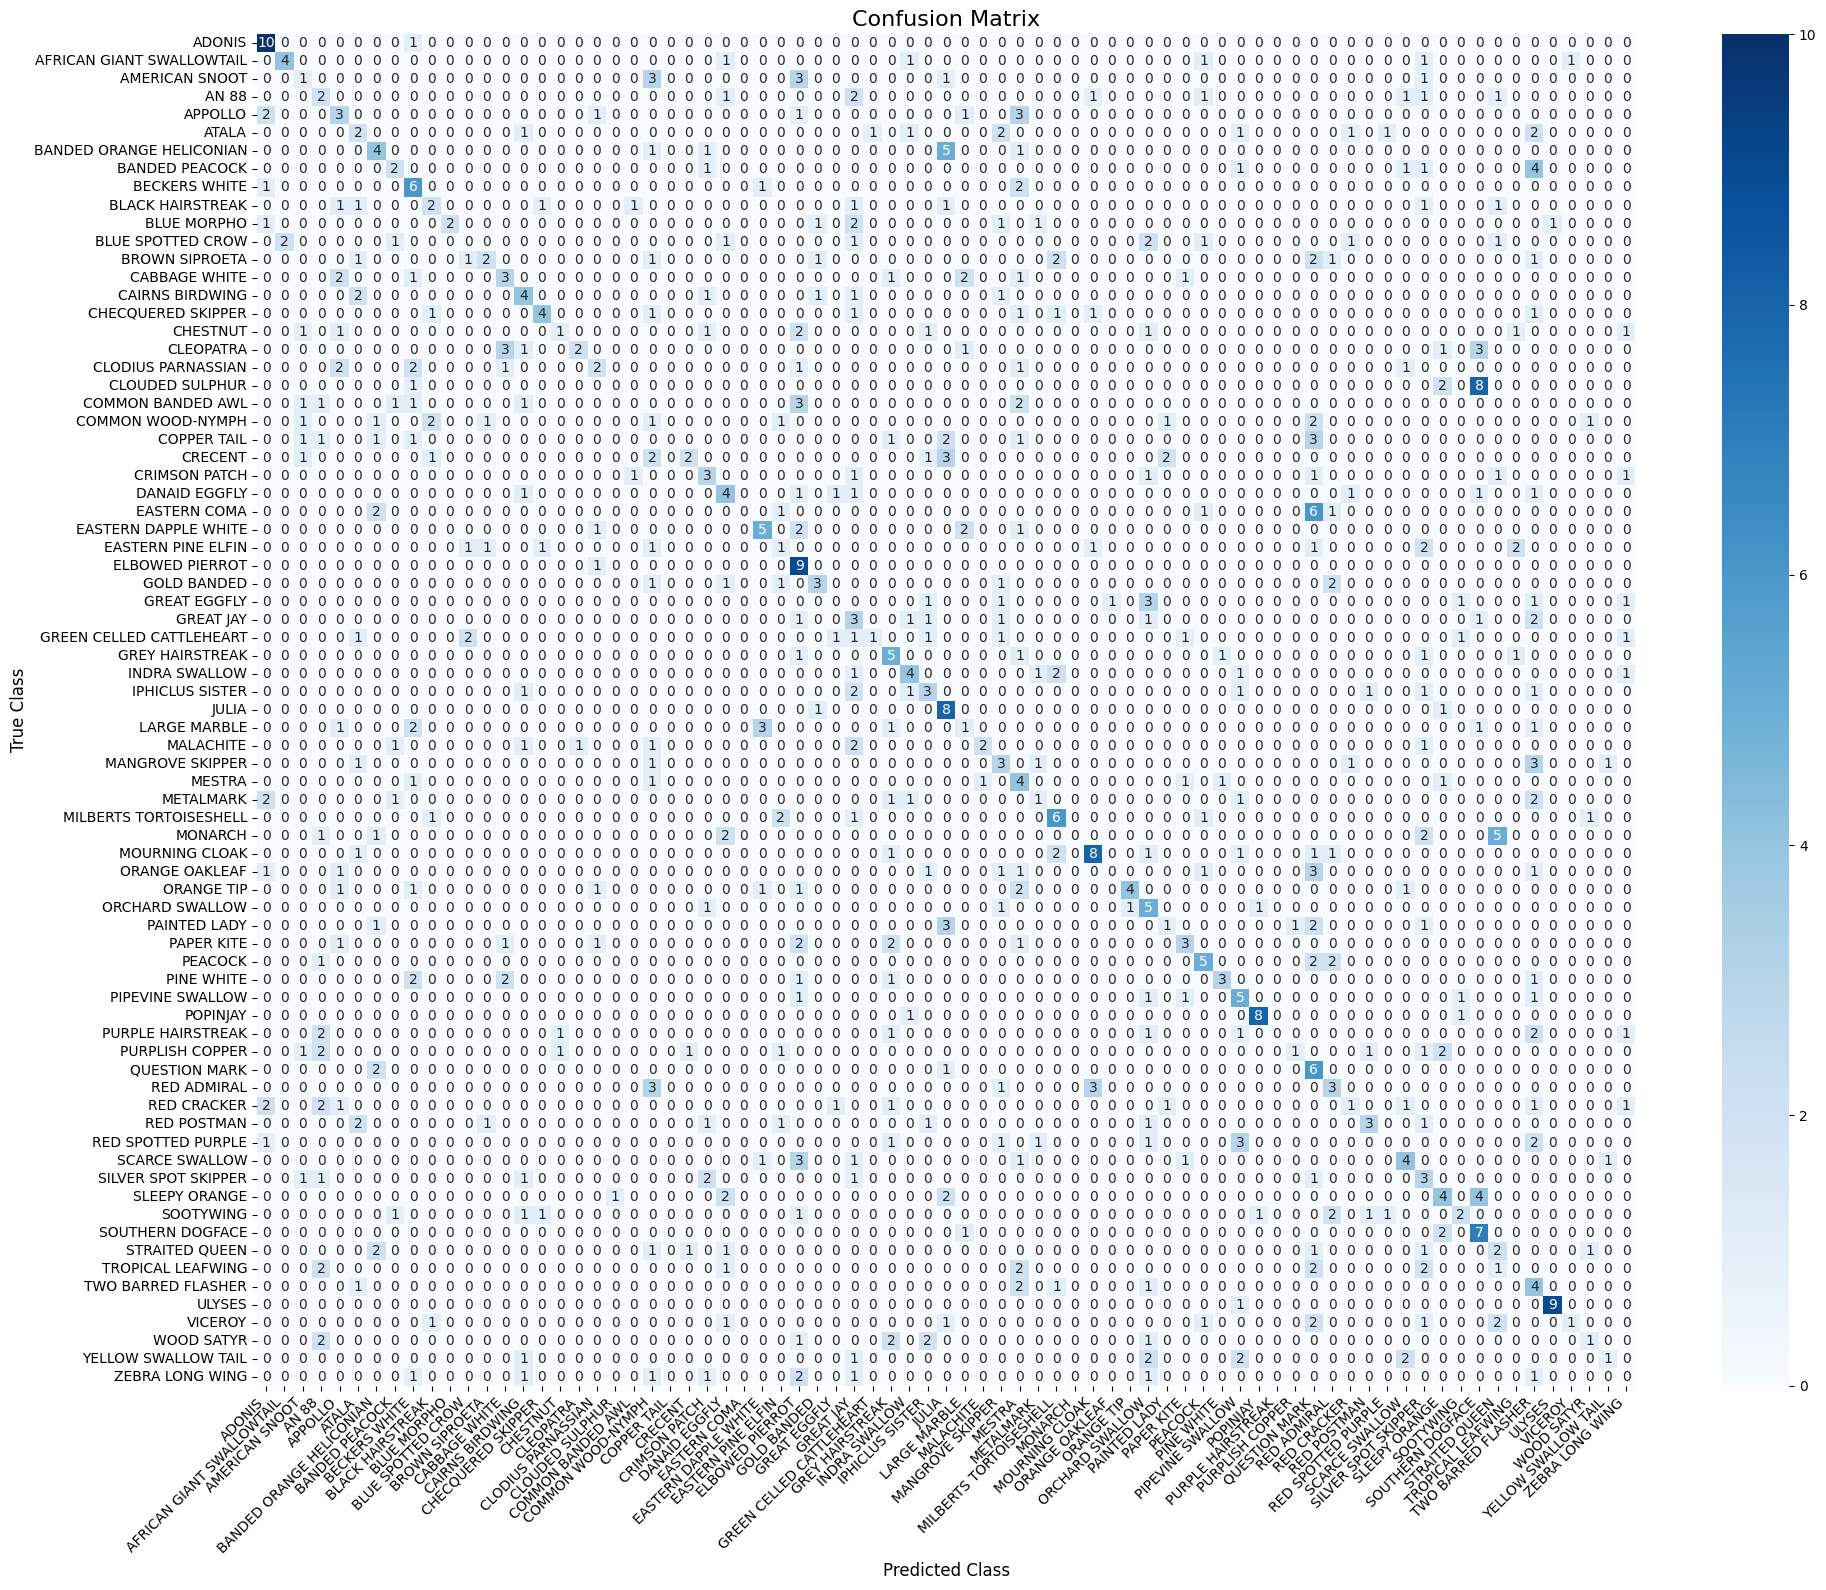

In [ ]:
final_mlp_model = ButterflyMLP(**mlp_args, **mlp_best_config['architecture']).to(device)

if mlp_best_config['loss'] == 'CrossEntropy':
    criterion_final = nn.CrossEntropyLoss()
else:
    criterion_final = nn.MultiMarginLoss()

if mlp_best_config['optimizer'] == 'Adam':
    optimizer_final = optim.Adam(final_mlp_model.parameters(), lr=mlp_best_config['learning_rate'])
else:
    optimizer_final = optim.RMSprop(final_mlp_model.parameters(), lr=mlp_best_config['learning_rate'])


print(f"Training the final MLP with the best configuration: {mlp_best_config}")
history_final = train_model(final_mlp_model, train_loader, val_loader, criterion_final, optimizer_final, device, num_epochs=10)

labels_reais, labels_previstos = evaluate_on_test(
    final_mlp_model, 
    test_loader, 
    device, 
    class_names=test_dataset.classes 
)